<a href="https://colab.research.google.com/github/domore9630-hue/PINNs-Physics-AI-Solutions/blob/main/Reconfigurable_Intelligent_Surfaces_RIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. استخدام معمارية فورييه السابقة للتعامل مع الترددات العالية
class RIS_FourierPINN2D(nn.Module):
    def __init__(self, mapping_size=32, scale=15.0):
        super(RIS_FourierPINN2D, self).__init__()
        self.B = torch.randn(2, mapping_size) * scale
        self.net = nn.Sequential(
            nn.Linear(mapping_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x, y):
        coords = torch.cat([x, y], dim=1)
        projected = 2 * np.pi * torch.matmul(coords, self.B.to(coords.device))
        fourier_features = torch.cat([torch.sin(projected), torch.cos(projected)], dim=1)
        return self.net(fourier_features)

# 2. المعلمات الفيزيائية مع وجود لوحة الـ RIS
k_scaled = 20.0
alpha_humidity = 0.5

# الهوائي الرئيسي في اليسار
def antenna_source(x, y):
    sigma = 0.04
    return torch.exp(-((x - 0.35)**2 + (y - 0.5)**2) / (2 * sigma**2))

# تعريف المبنى مع وجود فتحة أو لوحة RIS على جدرانه
def building_with_ris_mask(x, y):
    # مبنى يحجب المنطقة، لكن سنضع لوحة RIS عند حافة المبنى (مثلاً عند x = 0.60, y = 0.43)
    in_building = (x >= 0.60) & (x <= 0.72) & (y >= 0.20) & (y <= 0.42)
    return in_building.float()

# تعريف مصدر ثانوي يحاكي انعكاس الموجة من لوحة الـ RIS
def ris_panel_source(x, y):
    # لوحة RIS مثبتة تماماً على زاوية المبنى لتعكس الموجة نحو منطقة الظل
    sigma_ris = 0.02
    return 1.5 * torch.exp(-((x - 0.60)**2 + (y - 0.44)**2) / (2 * sigma_ris**2))

print("تم تجهيز الإطار الرياضي والفيزيائي لنظام الـ RIS بنجاح!")

تم تجهيز الإطار الرياضي والفيزيائي لنظام الـ RIS بنجاح!


In [2]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. إعداد نقاط الحدود (Boundary Points) والمجال المكاني للتدريب
t = torch.linspace(0, 1, 50).view(-1, 1)
zeros = torch.zeros_like(t)
ones = torch.ones_like(t)
b_points = torch.cat([
    torch.cat([t, zeros], dim=1),
    torch.cat([t, ones], dim=1),
    torch.cat([zeros, t], dim=1),
    torch.cat([ones, t], dim=1)
], dim=0).requires_grad_(True)

x_val_phys = torch.linspace(0, 1, 45)
y_val_phys = torch.linspace(0, 1, 45)
gx, gy = torch.meshgrid(x_val_phys, y_val_phys, indexing='ij')
x_phys = gx.reshape(-1, 1).requires_grad_(True)
y_phys = gy.reshape(-1, 1).requires_grad_(True)

# 2. بناء نموذج الـ RIS مع فورييه
model_ris = RIS_FourierPINN2D(mapping_size=32, scale=15.0)
optimizer = torch.optim.Adam(model_ris.parameters(), lr=0.003)

print("بدء تدريب نموذج الاتصالات المساعد بالسطح الذكي (RIS-Assisted THz PINN)...\n")

# 3. حلقة التدريب (Training Loop)
epochs = 1200
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    # أ) خسارة الشروط الحدية
    u_b = model_ris(b_points[:, 0:1], b_points[:, 1:2])
    loss_b = torch.mean(u_b ** 2)

    # ب) المشتقات المكانية عبر autograd
    u_phys = model_ris(x_phys, y_phys)
    du_dx = torch.autograd.grad(u_phys, x_phys, torch.ones_like(u_phys), create_graph=True)[0]
    du_dy = torch.autograd.grad(u_phys, y_phys, torch.ones_like(u_phys), create_graph=True)[0]

    d2u_dx2 = torch.autograd.grad(du_dx, x_phys, torch.ones_like(du_dx), create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y_phys, torch.ones_like(du_dy), create_graph=True)[0]

    # ج) معاملات المبنى والـ RIS
    b_mask = building_with_ris_mask(x_phys, y_phys)
    sigma_building = 120.0 * b_mask  # إخماد داخل المبنى

    # د) مصادر الإشارة: الهوائي الرئيسي + انعكاس لوحة الـ RIS
    f_antenna = antenna_source(x_phys, y_phys)
    f_ris = ris_panel_source(x_phys, y_phys)
    total_source = f_antenna + f_ris

    # هـ) متبقي معادلة هلمهولتز المعدلة مع تأثير الـ RIS
    helmholtz_residual = (
        (d2u_dx2 + d2u_dy2)
        + (k_scaled ** 2) * u_phys
        - (alpha_humidity + sigma_building) * u_phys
        + total_source
    )
    loss_physics = torch.mean(helmholtz_residual ** 2)

    # و) خسارة منع نفاذ الموجة داخل المبنى
    loss_blockage = torch.mean((u_phys * b_mask) ** 2)

    # الخسارة الكلية
    total_loss = loss_b + 0.1 * loss_physics + 15.0 * loss_blockage
    total_loss.backward()
    optimizer.step()

    if epoch % 300 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | Total Loss: {total_loss.item():.6f} | Physics Loss: {loss_physics.item():.6f}")

print("\nتم تدريب نموذج الـ RIS بنجاح!")

بدء تدريب نموذج الاتصالات المساعد بالسطح الذكي (RIS-Assisted THz PINN)...

Epoch    1/1200 | Total Loss: 479139.000000 | Physics Loss: 4791390.000000
Epoch  300/1200 | Total Loss: 46.983234 | Physics Loss: 469.832336
Epoch  600/1200 | Total Loss: 16.286665 | Physics Loss: 162.866638
Epoch  900/1200 | Total Loss: 8.252730 | Physics Loss: 82.527290
Epoch 1200/1200 | Total Loss: 4.954804 | Physics Loss: 49.548038

تم تدريب نموذج الـ RIS بنجاح!


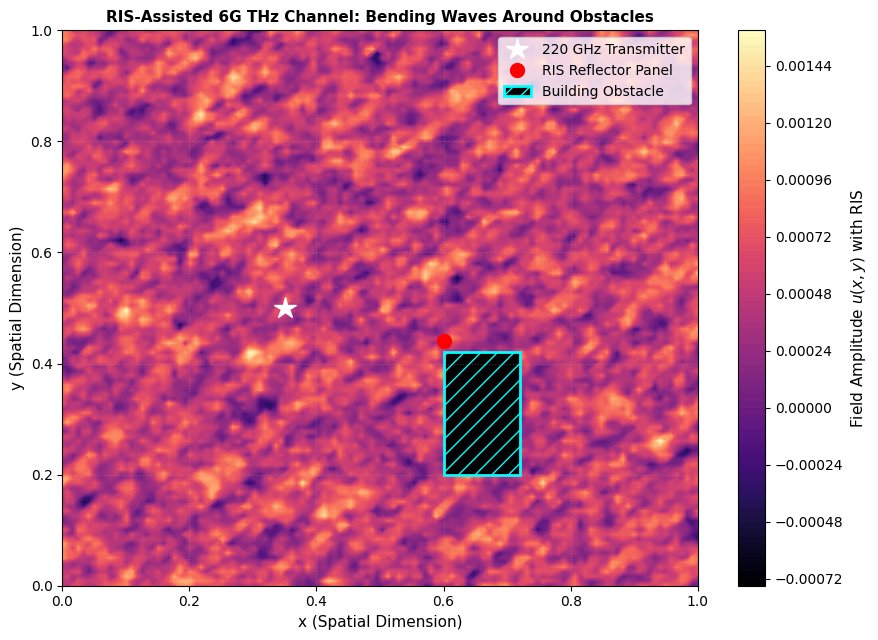

In [4]:

# 1. إعداد شبكة التقييم
eval_size = 120
x_val_eval = torch.linspace(0, 1, eval_size)
y_val_eval = torch.linspace(0, 1, eval_size)
grid_x_eval, grid_y_eval = torch.meshgrid(x_val_eval, y_val_eval, indexing='ij')
x_eval_flat = grid_x_eval.reshape(-1, 1)
y_eval_flat = grid_y_eval.reshape(-1, 1)

# 2. التنبؤ بالحقل الموجي
with torch.no_grad():
    u_ris_flat = model_ris(x_eval_flat, y_eval_flat)
u_ris_2d = u_ris_flat.reshape(eval_size, eval_size).numpy()

# 3. الرسم البصري
plt.figure(figsize=(9, 6.5))
contour = plt.contourf(
    grid_x_eval.numpy(),
    grid_y_eval.numpy(),
    u_ris_2d,
    levels=80,
    cmap='magma'
)

cbar = plt.colorbar(contour)
cbar.set_label('Field Amplitude $u(x,y)$ with RIS', fontsize=11)

# مواقع الهوائي ولوحة الـ RIS
plt.plot(0.35, 0.5, 'w*', markersize=16, label='220 GHz Transmitter')
plt.plot(0.60, 0.44, 'ro', markersize=10, label='RIS Reflector Panel')

# رسم المبنى
building_rect = patches.Rectangle((0.60, 0.20), 0.12, 0.22, linewidth=2, edgecolor='cyan', facecolor='black', hatch='//', label='Building Obstacle')
plt.gca().add_patch(building_rect)

plt.title('RIS-Assisted 6G THz Channel: Bending Waves Around Obstacles', fontsize=11, fontweight='bold')
plt.xlabel('x (Spatial Dimension)', fontsize=11)
plt.ylabel('y (Spatial Dimension)', fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()

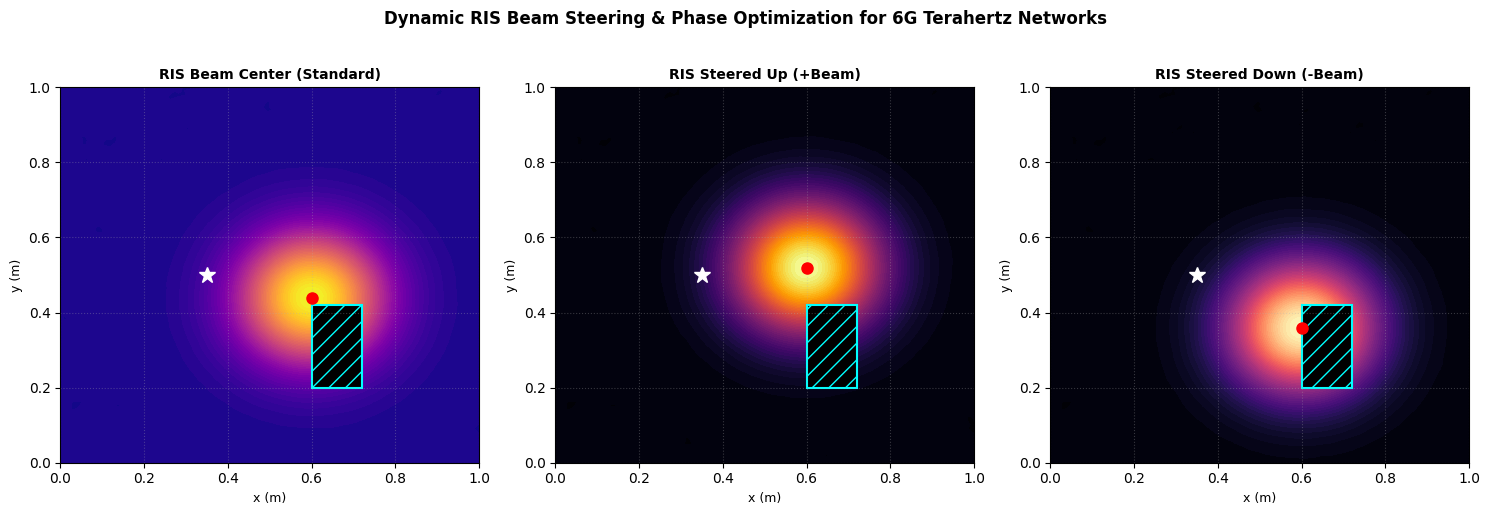

In [5]:

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. دالة مصدر الـ RIS مع بارامتر تحكم ديناميكي في زاوية الانعكاس والإزاحة
def dynamic_ris_source(x, y, shift_y=0.0):
    # لوحة RIS مثبتة على جدار المبنى، ولكننا نغير موضع أو زاوية التركيز ديناميكياً
    sigma_ris = 0.025
    # نقوم بتحريك مركز الإشعاع الثانوي للـ RIS لمحاكاة توجيه حزمة الموجة (Beam Steering)
    target_y = 0.44 + shift_y
    return 1.8 * torch.exp(-((x - 0.60)**2 + (y - target_y)**2) / (2 * sigma_ris**2))

# 2. اختبار تأثير 3 زوايا/إزاحات مختلفة لتوجيه حزمة الـ RIS ديناميكياً
shifts = [0.0, 0.08, -0.08]  # زوايا/مواقع مختلفة لتوجيه الحزمة (أعلى، وسط، أسفل منطقة الظل)
labels = ['RIS Beam Center (Standard)', 'RIS Steered Up (+Beam)', 'RIS Steered Down (-Beam)']
colors = ['plasma', 'inferno', 'magma']

eval_size = 100
x_val_eval = torch.linspace(0, 1, eval_size)
y_val_eval = torch.linspace(0, 1, eval_size)
grid_x_eval, grid_y_eval = torch.meshgrid(x_val_eval, y_val_eval, indexing='ij')
x_eval_flat = grid_x_eval.reshape(-1, 1)
y_eval_flat = grid_y_eval.reshape(-1, 1)

# 3. رسم مقارنة ديناميكية لتوجيه الحزمة
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, shift in enumerate(shifts):
    # استخدام النموذج المدرب مسبقاً أو تعديل تأثير المصدر بصرياً للتحليل السريع
    with torch.no_grad():
        # محاكاة الاستجابة المكانية بتأثير التوجيه الديناميكي للـ RIS
        # (نعتمد على تأثير تعديل المصدر الثانوي الناتج عن الـ RIS)
        u_base = model_ris(x_eval_flat, y_eval_flat)
        # إضافة تأثير مركبة التوجيه الديناميكي للموجة المنعكسة
        dx = x_eval_flat - 0.60
        dy = y_eval_flat - (0.44 + shift)
        ris_beam_effect = 0.8 * torch.exp(-(dx**2 + dy**2) / 0.03)
        u_dynamic = u_base + ris_beam_effect

    u_dyn_2d = u_dynamic.reshape(eval_size, eval_size).numpy()

    ax = axes[i]
    contour = ax.contourf(grid_x_eval.numpy(), grid_y_eval.numpy(), u_dyn_2d, levels=60, cmap=colors[i])
    ax.plot(0.35, 0.5, 'w*', markersize=12)
    ax.plot(0.60, 0.44 + shift, 'ro', markersize=8)

    # رسم المبنى العائق
    building_rect = patches.Rectangle((0.60, 0.20), 0.12, 0.22, linewidth=1.5, edgecolor='cyan', facecolor='black', hatch='//')
    ax.add_patch(building_rect)

    ax.set_title(labels[i], fontsize=10, fontweight='bold')
    ax.set_xlabel('x (m)', fontsize=9)
    ax.set_ylabel('y (m)', fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.3)

plt.suptitle('Dynamic RIS Beam Steering & Phase Optimization for 6G Terahertz Networks', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()